In [1]:
# --- セル1: ライブラリの準備 ---
import pandas as pd
import numpy as np
import torch
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.auto import tqdm

# Transformers & Captum
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from captum.attr import LayerIntegratedGradients

# 日本語フォント設定
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# デバイス設定 (GPUが使えるならGPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# --- セル2: データ読み込みと分析用データの作成 ---

# CSVパス (環境に合わせて変更してください)
csv_path = 'dataset/narou_dataset.csv'
df = pd.read_csv(csv_path)

# 欠損値埋め
df['あらすじ'] = df['あらすじ'].fillna('')

# ===========================================================
# ★URLを <URL> に置換する処理
# ===========================================================
def clean_url(text):
    return re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '<URL>', str(text))

df['あらすじ'] = df['あらすじ'].apply(clean_url)
print("URLの正規化が完了しました。")

# ===========================================================
# ジャンル設定とデータ抽出
# ===========================================================

# ジャンルマップ (変更時に確認用)
genres_map = {
    0: '未設定', 101: '異世界（恋愛）', 102: '現実世界（恋愛）', 201: 'ハイファンタジー', 202: 'ローファンタジー',
    301: '純文学', 302: 'ヒューマンドラマ', 303: '歴史', 304: '推理', 305: 'ホラー',
    306: 'アクション', 307: 'コメディー', 401: 'VRゲーム', 402: '宇宙', 403: '空想科学',
    404: 'パニック', 9901: '童話', 9902: '詩', 9903: 'エッセイ', 9904: 'リプレイ',
    9999: 'その他', 9801: 'ノンジャンル'
}

# ★分析したいジャンルIDを指定
TARGET_GENRE_ID = 101
target_genre_name = genres_map.get(TARGET_GENRE_ID, '指定ジャンル')

# ★分析に使用するサンプル数 (多すぎると時間がかかります)
NUM_SAMPLES = 5000

# ジャンル抽出
if TARGET_GENRE_ID != 0:
    df_genre = df[df['作品ジャンル'] == TARGET_GENRE_ID].copy()
else:
    df_genre = df.copy()

print(f"対象ジャンル: {target_genre_name} (全{len(df_genre)}件)")

# エタる(1)と完結(0)のデータを抽出して均衡化
df_eternal = df_genre[df_genre['is_eternal'] == 1]
df_complete = df_genre[df_genre['is_eternal'] == 0]

analyze_size = min(NUM_SAMPLES, len(df_eternal), len(df_complete))

df_balanced = pd.concat([
    df_eternal.sample(n=analyze_size, random_state=42),
    df_complete.sample(n=analyze_size, random_state=42)
])

# 'text' カラムを作成（分析ループで使用）
df_balanced['text'] = df_balanced['あらすじ']

print(f"分析用データ数: {len(df_balanced)}件 (各クラス {analyze_size}件)")

URLの正規化が完了しました。
対象ジャンル: 異世界（恋愛） (全48842件)
分析用データ数: 10000件 (各クラス 5000件)


In [3]:
# --- セル3: モデルとトークナイザのロード ---

# ベースモデル名
BASE_MODEL_NAME = "tohoku-nlp/bert-large-japanese-v2"

# ★学習済みモデルのパス設定
# (例: 学習コードの出力先ディレクトリに合わせて書き換えてください)
# フォルダ構成例: result_bert/genre_101/checkpoint-300
BASE_OUTPUT_DIR = "result_" 

genre_checkpoint_map = {
    0:   "checkpoint-300", 
    101: "checkpoint-300", # 異世界（恋愛）
    102: "checkpoint-300", 
    201: "checkpoint-300", 
    202: "checkpoint-300", 
}

# パスの構築
chk_name = genre_checkpoint_map.get(TARGET_GENRE_ID, "checkpoint-300")

# ※ディレクトリ構造に合わせて適宜修正してください。
# もし直下にcheckpointフォルダがある場合はパスを調整してください。
model_path = os.path.join(f"{BASE_OUTPUT_DIR}{genres_map[TARGET_GENRE_ID]}/", chk_name)

# もしパスが存在しない場合は、パスの書き方を調整するか確認してください
if not os.path.exists(model_path):
    print(f"Warning: 指定されたパスが見つかりません: {model_path}")
    print("とりあえずチェックポイント名そのものをパスとして試行します...")
    model_path = chk_name

print(f"モデルをロードします: {model_path}")

# トークナイザとモデルの読み込み
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
model.to(device)
model.eval()

print("モデル準備完了。")

モデルをロードします: result_異世界（恋愛）/checkpoint-300
モデル準備完了。


In [4]:
# --- セル4: Captumによる重要語分析の実行 ---

# 集計用辞書
# key: 単語, value: スコアの合計
word_scores = defaultdict(float)

# 予測関数のラッパー (Captum用)
def predict_func(input_ids, attention_mask=None):
    return model(input_ids=input_ids, attention_mask=attention_mask).logits

# LayerIntegratedGradientsの設定
# bert-large-japanese-v2 の場合、Embedding層は model.bert.embeddings です
lig = LayerIntegratedGradients(predict_func, model.bert.embeddings)

print(f"集計を開始します（分析対象: {len(df_balanced)}件）...")

for text in tqdm(df_balanced['text'], desc="Analyzing"):
    # トークナイズ
    inputs = tokenizer(
        text, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=512
    ).to(device)
    
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']

    # ターゲットを「1: エタる」に固定して貢献度を計算
    # bert-largeはメモリを食うため internal_batch_size=1 推奨
    attributions = lig.attribute(
        inputs=input_ids,
        baselines=torch.zeros_like(input_ids),
        target=1, 
        additional_forward_args=(attention_mask, ),
        internal_batch_size=1 
    )

    # トークンごとにスコアを合算
    # (1, seq_len, hidden_size) -> (seq_len)
    attr_sum = attributions.sum(dim=2).squeeze(0).cpu().detach().numpy()
    
    # IDをトークン(文字列)に戻す
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    for token, score in zip(tokens, attr_sum):
        word_scores[token] += score

print("全作品の集計が完了しました。次のセルで可視化を行います。")

集計を開始します（分析対象: 10000件）...


Analyzing:   0%|          | 0/10000 [00:00<?, ?it/s]

全作品の集計が完了しました。次のセルで可視化を行います。


C:\Users\blast\AppData\Local\Temp\ipykernel_23308\2079893632.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='累積スコア', y='単語', data=top_eternal, ax=axes[0], palette='Reds_r')
C:\Users\blast\AppData\Local\Temp\ipykernel_23308\2079893632.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='累積スコア', y='単語', data=top_complete, ax=axes[1], palette='Blues_r')


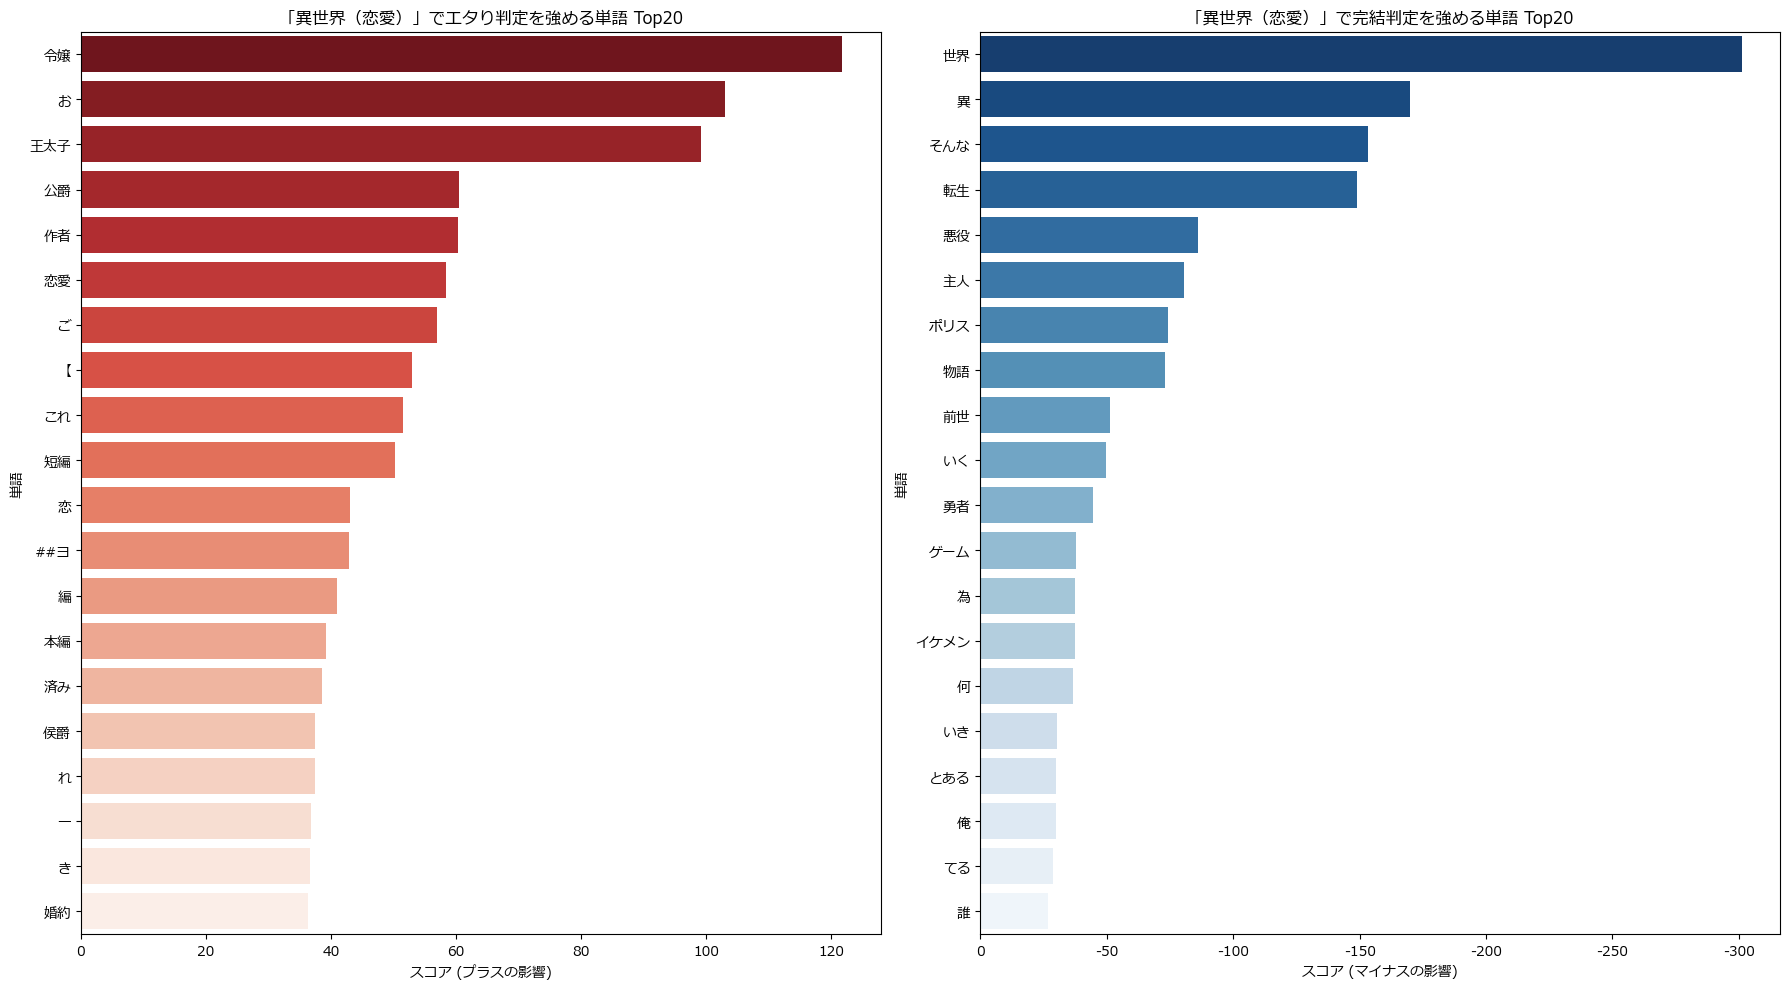

【エタる要因 Top10】
 単語      累積スコア
 令嬢 121.779768
  お 103.022785
王太子  99.201565
 公爵  60.515605
 作者  60.365162
 恋愛  58.308198
  ご  57.000386
  【  52.901895
 これ  51.541058
 短編  50.214423

【完結要因 Top10】
 単語       累積スコア
 世界 -301.222473
  異 -169.934677
そんな -153.309937
 転生 -149.073768
 悪役  -85.973094
 主人  -80.709304
ポリス  -74.350527
 物語  -72.955181
 前世  -51.283744
 いく  -49.567936


In [5]:
# --- セル5: 結果の可視化 (ストップワード除去) ---

stop_words = [
    # 助詞・助動詞（既存）
    'の', 'に', 'は', 'を', 'が', 'と', 'て', 'で', 'た', 'も', 
    'な', 'だ', 'し', 'か', 'ら', 'よ', 'ね', 'ば', 'へ', 'や', 
    'から', 'ので', 'のに', 'ある', 'いる', 'こと', 'する', 'ない', 'なる',
    'れる', 'られる', 'ます', 'です', 'う', 'よう', 'ませ', 'たい',
    'い', 'ん', 'その', 'この', 'いう', 'ください',
    
    # 記号・特殊文字（今回判明したものを追加）
    '、', '。', '！', '？', '!', '?', '・', '…', '..',
    '「', '」', '（', '）', '(', ')', '『', '』', 'ー', '-', ' ', '　',
    '.', ',', '※', '*', '/', ':', # ★追加: 記号類
    
    # メタ情報・事務連絡（今回判明したものを追加）
    '完結', '投稿', '掲載', '作品', '更新', '話', '連載', 
    'カク', 'ヨム', 'サイト', '転載', '感想', '評価', 'ブクマ',
    
    # BERT特有
    '[UNK]', '[PAD]', '[CLS]', '[SEP]',

    'ー',  # 一般的な長音（カタカナの後ろなど）
    '―',  # 全角ダッシュ（小説で「――」のように強調で使われる）
    '‐',  # 全角ハイフン
    '－',  # 全角マイナス（ダッシュの代用として使われることがある）
    '-',  # 半角ハイフン
    '〜',  # 全角チルダ（「だよ〜」など）
    '~',  # 半角チルダ
    '─',  # 罫線（ダッシュの代用）
    '−'   # 数学記号のマイナス（これも混入しやすい）
]

# データフレーム化
importance_df = pd.DataFrame(word_scores.items(), columns=['単語', '累積スコア'])

# --- フィルタリング処理 ---
# 1. ストップワードの除去
importance_df = importance_df[~importance_df['単語'].isin(stop_words)]

# 2. BERTのサブワード(##で始まるもの)を除去するかはお好みで
# importance_df = importance_df[~importance_df['単語'].str.startswith('##')]

# 上位・下位20件を抽出
top_eternal = importance_df.sort_values('累積スコア', ascending=False).head(20)
top_complete = importance_df.sort_values('累積スコア', ascending=True).head(20)

# グラフ描画
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# エタる要因
sns.barplot(x='累積スコア', y='単語', data=top_eternal, ax=axes[0], palette='Reds_r')
axes[0].set_title(f'「{target_genre_name}」でエタり判定を強める単語 Top20')
axes[0].set_xlabel('スコア (プラスの影響)')

# 完結要因
sns.barplot(x='累積スコア', y='単語', data=top_complete, ax=axes[1], palette='Blues_r')
axes[1].set_title(f'「{target_genre_name}」で完結判定を強める単語 Top20')
axes[1].set_xlabel('スコア (マイナスの影響)')
axes[1].invert_xaxis() 

plt.tight_layout()
plt.show()

# テキスト出力
print("【エタる要因 Top10】")
print(top_eternal[['単語', '累積スコア']].head(10).to_string(index=False))
print("\n【完結要因 Top10】")
print(top_complete[['単語', '累積スコア']].head(10).to_string(index=False))